In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src import preprocessing

# 1. Read in Data

In [9]:
G = pd.read_csv('../G.csv', sep = '|')
STrain = pd.read_csv('../STrain.csv', sep = '|')

In [10]:
G["name_clean"] = G["name"].apply(preprocessing.preprocess_company_name)
STrain["name_clean"] = STrain["name"].apply(preprocessing.preprocess_company_name)

In [11]:
G.head()

,company_id,name,name_clean
0,634022,PRIMCOM SA,primcom
1,324497,The David Isaacs Fund,the david isaacs fund
2,280848,Bramor Enterprises Limited,bramor enterprises
3,432662,NAVEXIM S.A.,navexim
4,524224,Magal Group SA,magal group


# 2. Missing data

In [12]:
G.isna().sum().sort_values(ascending=False)

company_id    0
name          0
name_clean    0
dtype: int64

# 3. Check duplicates
## 3.1 company_id

In [13]:
G['company_id'].nunique(), len(G)

(450256, 450256)

## 3.2 Names

In [15]:
print(G['name'].duplicated().sum())
print(G['name_clean'].duplicated().sum())

1507
15007


In [25]:
# Inspect some duplicates
G[G['name'].duplicated(keep=False)].sort_values('name').head(20)

,company_id,name,name_clean
240678,491883,"""MERCURY S.R.L.""",mercury
106188,398982,"""MERCURY S.R.L.""",mercury
120122,604192,A. Lacroix & Fils Granit Ltée,lacroix fils granit ltee
271147,214469,A. Lacroix & Fils Granit Ltée,lacroix fils granit ltee
264731,362501,A.T.I. S.R.L.,
225020,360050,A.T.I. S.R.L.,
137402,387188,A.V.S. S.R.L.,
12808,528010,A.V.S. S.R.L.,
155937,637309,"AB Bond Fund, Inc. - AB Income Fund",bond fund income fund
449488,585880,"AB Bond Fund, Inc. - AB Income Fund",bond fund income fund


# 4. Name Length Analysis

In [ ]:
# Check name length (characters)
G['name_len'] = G['name'].str.len()
G['clean_len'] = G['name_clean'].str.len()

G[['name_len','clean_len']].describe()

,name_len,clean_len
count,450256.000000,450256.00000
mean,29.914586,25.20153
std,17.464374,17.30900
min,1.000000,0.00000
25%,19.000000,14.00000
50%,26.000000,21.00000
75%,36.000000,31.00000
max,307.000000,290.00000


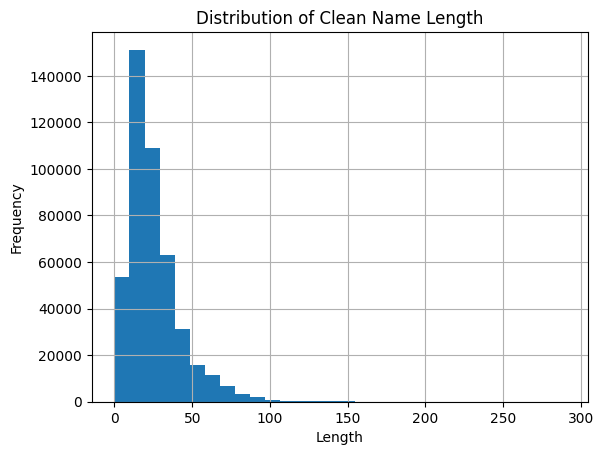

In [40]:
G['clean_len'].hist(bins=30)
plt.title('Distribution of Clean Name Length')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()

In [49]:
# Check amount of very short names
print(len(G[G['name_len'] <= 3]))
G[G['name_len'] <= 3].head(10)

362


,company_id,name,name_clean,name_len,clean_len
3683,91425,Bac,bac,3,3
17148,611556,IA,ia,2,2
17311,599360,CVS,cvs,3,3
24870,284941,18M,18m,3,3
27536,544538,GCH,gch,3,3
27560,513266,FLW,flw,3,3
30256,159060,GBA,gba,3,3
30257,208433,XL4,xl4,3,3
30267,330731,E2F,e2f,3,3
34824,118059,GMC,gmc,3,3


# 4.1 Multi-token names

In [ ]:
G['name_token_count'] = G['name'].str.split().str.len()
G['clean_token_count'] = G['name_clean'].str.split().str.len()
pd.melt(
    G[['name_token_count', 'clean_token_count']],
    value_name='token_count'
).value_counts().unstack(0).sort_index().head(15)

variable,name_token_count,clean_token_count
token_count,,
0,NaN,1126.0
1,7108.0,47906.0
2,63449.0,126444.0
3,121992.0,109538.0
4,96503.0,63356.0
5,59215.0,37081.0
6,35287.0,21842.0
7,20832.0,13638.0
8,14490.0,9937.0


# 5. Character Quality Checks

In [ ]:
G['has_digit'] = G['name'].str.contains(r'\d', regex=True)
print(G['has_digit'].mean())
G[G['has_digit']].head(20)

0.09534353789844


,company_id,name,name_clean,name_len,clean_len,token_count,has_digit,name_token_count,clean_token_count,has_special
7,381944,VX 30.141 ApS,vx 30 141,13,9,3,True,3,3,True
8,526057,Rydex ETF Trust - Guggenheim S&P 500 Equal Wei...,rydex etf trust guggenheim 500 equal weight etf,53,47,10,True,10,8,True
24,80822,Strandtorget 1 AS,strandtorget,17,12,3,True,3,1,False
38,209095,MSR Anaconda AV1A Corp.,msr anaconda av1a,23,17,4,True,4,3,True
73,516117,Invest 88 A/S,invest 88,13,9,3,True,3,2,True
83,589060,813 Capital Investment,813 capital investment,22,22,3,True,3,3,True
92,210456,Håndværkerstiftelsen af 1835,handvaerkerstiftelsen af 1835,28,29,3,True,3,3,True
114,520279,Sagax Finland Holding 10 Oy,sagax finland holding 10,27,24,5,True,5,4,True
127,611664,Rydex ETF Trust - Guggenheim S&P 500 Pure Grow...,rydex etf trust guggenheim 500 pure growth etf,52,46,10,True,10,8,True
131,97499,Barings Global Special Situations Credit 3 S.à...,barings global special situations credit,51,40,8,True,8,5,False


# 6. Overview of repeated names

In [111]:
# n excluding all entries of a duplicated entity
print("Unique entries:", G['company_id'].nunique())
print("Raw unique names:", G['name'].drop_duplicates(keep=False).nunique())
print("Clean unique names:", G['name_clean'].drop_duplicates(keep=False).nunique())

Unique entries: 450256
Raw unique names: 447379
Clean unique names: 426551


In [112]:
# view companies with same name but with multiple company_ids
G["name"].value_counts().head(20)

name
Raiffeisenbank eG             15
Volksbank eG                  12
First State Bank              10
First Bank & Trust             6
First National Bank            5
The First State Bank           5
Citizens Bank                  5
Peoples Bank                   5
AURORA S.R.L.                  5
GENESI S.R.L.                  5
VR-Bank eG                     5
First Federal Savings Bank     4
VEGA S.R.L.                    4
The Salvation Army             4
First Community Bank           4
Fidelity Bank                  4
Farmers State Bank             4
The Peoples Bank               4
United Bank                    4
FUTURA S.R.L.                  4
Name: count, dtype: int64

In [ ]:
# view companies with same name_clean but with multiple company_ids
G["name_clean"].value_counts().head(20)

name_clean
                 1126
holding           194
invest             79
immobiliare        77
investments        66
beheer             63
group              58
properties         56
international      51
holdings           43
real estate        37
spol               32
management         31
realty             31
enterprises        28
co                 25
trading            25
associates         24
siemens            24
capital            22
Name: count, dtype: int64